# 🔍 EDA Completo
## DataTalent Solutions S.L. · Módulo II: Análisis y Visualización de Datos

Este notebook realiza un **Análisis Exploratorio de Datos (EDA) completo** sobre salarios de profesionales de datos en España, con el objetivo de responder a las siguientes preguntas de negocio:

- ¿Qué skills técnicas se demandan con más frecuencia en roles de datos en España?
- ¿Existen sesgos en la distribución salarial según género, ciudad o tipo de contrato?
- ¿Qué sectores concentran más ofertas y mejores salarios?
- ¿Qué correlaciones existen entre experiencia, skills y salario?
- ¿Qué decisiones podrían tomarse erróneamente si los datos presentan sesgos?

**Dataset:** *Data Science Job Salaries* (Kaggle) — salarios globales 2020–2025 en roles de datos.  
**Fuente:** El dataset global contiene 105.434 registros de 98 países. En este análisis filtramos exclusivamente los registros de España (`employee_residence = 'ES'`).


---
## 📦 Fase 1 — Exploración inicial del dataset global

En esta fase cargamos el dataset completo, inspeccionamos su estructura y realizamos la exploración inicial **antes** de filtrar por España.  
El objetivo es entender qué columnas contiene, qué tipos de datos hay y detectar nulos en el total.


### 1️⃣ Importar librerías y cargar el dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', 20)

# Cargar dataset global
df = pd.read_csv("salaries.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Analist,65664,EUR,69120,NL,0,NL,M
1,2025,EN,FT,Data Analist,47652,EUR,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,USD,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,USD,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M


### 2️⃣ Dimensiones del dataset global

Comprobamos cuántas filas y columnas contiene el dataset antes de aplicar ningún filtro.

In [2]:
print(f"Dimensiones del dataset global: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dimensiones del dataset global: 105,434 filas × 11 columnas


### 3️⃣ Información general y tipos de datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105434 entries, 0 to 105433
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           105434 non-null  int64 
 1   experience_level    105434 non-null  object
 2   employment_type     105434 non-null  object
 3   job_title           105434 non-null  object
 4   salary              105434 non-null  int64 
 5   salary_currency     105434 non-null  object
 6   salary_in_usd       105434 non-null  int64 
 7   employee_residence  105434 non-null  object
 8   remote_ratio        105434 non-null  int64 
 9   company_location    105434 non-null  object
 10  company_size        105434 non-null  object
dtypes: int64(4), object(7)
memory usage: 8.8+ MB


### 4️⃣ Identificación de variables numéricas y categóricas

Separamos las variables por tipo para poder aplicar técnicas adecuadas a cada una en las fases de limpieza y análisis.

In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Variables numéricas:", numerical_cols)
print("Variables categóricas:", categorical_cols)

Variables numéricas: ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']
Variables categóricas: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


### 5️⃣ Detección de valores nulos en el dataset global

In [5]:
nulls_global = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentaje (%)": round(df.isnull().sum() / len(df) * 100, 2)
}).sort_values("Porcentaje (%)", ascending=False)

nulls_global

,Nulos,Porcentaje (%)
work_year,0,0.00
experience_level,0,0.00
employment_type,0,0.00
job_title,0,0.00
salary,0,0.00
salary_currency,0,0.00
salary_in_usd,0,0.00
employee_residence,0,0.00
remote_ratio,0,0.00
company_location,0,0.00


---
## 🇪🇸 Fase 1B — Filtrado por España: todos los análisis posteriores se realizan sobre este subconjunto

Utilizamos `employee_residence == 'ES'` en lugar de `company_location` porque nuestro objetivo es analizar las condiciones de los **profesionales que viven y trabajan en España**.  
En la era del trabajo remoto, un analista puede residir en España y trabajar para una empresa con sede en otro país; usar `company_location` haría que perdiéramos de vista el salario real y las oportunidades accesibles desde nuestro país.

> ⚠️ **A partir de este punto, todo el análisis se realiza exclusivamente sobre `df_espana`.**


In [6]:
# Filtrar únicamente registros de personas residentes en España
df_espana = df[df['employee_residence'] == 'ES'].copy()

print(f"Registros de España: {len(df_espana):,} ({len(df_espana)/len(df)*100:.1f}% del total global)")
print(f"Período analizado: {df_espana['work_year'].min()} – {df_espana['work_year'].max()}")
df_espana.head()

Registros de España: 233 (0.2% del total global)
Período analizado: 2020 – 2025


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
1352,2025,MI,FT,AI Engineer,46000,EUR,48421,ES,0,ES,M
1353,2025,MI,FT,AI Engineer,26000,EUR,27368,ES,0,ES,M
2700,2025,SE,FT,Data Engineer,40000,EUR,42105,ES,0,ES,M
2701,2025,SE,FT,Data Engineer,35000,EUR,36842,ES,0,ES,M
3138,2025,MI,FT,Backend Developer,32000,EUR,33684,ES,100,ES,M


---
## 🧹 Fase 2 — Limpieza y preparación de los datos de España

Una vez filtrado el subconjunto español, procedemos a limpiar y preparar los datos para el análisis.


### 6️⃣ Detección de valores nulos en España

In [ ]:
nulls_espana = pd.DataFrame({
    "Nulos": df_espana.isnull().sum(),
    "Porcentaje (%)": round(df_espana.isnull().sum() / len(df_espana) * 100, 2)
}).sort_values("Porcentaje (%)", ascending=False)

nulls_espana

**Interpretación:** El subconjunto de España no presenta valores nulos, por lo que no es necesario aplicar imputación ni eliminación de registros.  
No obstante, esto **no descarta la posibilidad de sesgos MNAR** (Missing Not At Random, valores no aleatorios faltantes), ya que el origen de los datos puede haber filtrado ciertos perfiles de forma sistemática. Esto se analiza en profundidad en la Fase 3 de sesgos.


### 7️⃣ Detección y análisis de duplicados

In [7]:
spain_duplicates = df_espana.duplicated().sum()

# Frecuencia de cada combinación duplicada
duplicates_freq = (
    df_espana
    .groupby(list(df_espana.columns))
    .size()
    .reset_index(name='frequency')
    .query('frequency > 1')
    .sort_values('frequency', ascending=False)
)

print(f"Registros duplicados en España: {spain_duplicates}")
print(f"Combinaciones distintas duplicadas: {len(duplicates_freq)}")
duplicates_freq.head(10)

Registros duplicados en España: 69
Combinaciones distintas duplicadas: 26


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,frequency
55,2023,SE,FT,Data Scientist,45000,EUR,48585,ES,0,ES,M,14
53,2023,SE,FT,Data Scientist,36000,EUR,38868,ES,0,ES,M,14
25,2022,SE,FT,Data Scientist,36000,EUR,37824,ES,0,ES,M,7
26,2022,SE,FT,Data Scientist,45000,EUR,47280,ES,0,ES,M,7
19,2022,SE,FT,Data Analyst,48000,EUR,50432,ES,0,ES,M,4
117,2024,SE,FT,Software Engineer,115000,EUR,127777,ES,100,ES,M,4
116,2024,SE,FT,Software Engineer,85000,EUR,94444,ES,100,ES,M,4
20,2022,SE,FT,Data Engineer,35000,EUR,36773,ES,0,ES,M,3
22,2022,SE,FT,Data Engineer,65000,EUR,68293,ES,0,ES,M,3
17,2022,SE,FT,Data Analyst,35000,EUR,36773,ES,0,ES,M,3


**Análisis crítico de duplicados:** Las repeticiones observadas tienen frecuencias bajas y coherentes. Se corresponden con perfiles genéricos (p. ej. *Data Scientist* junior con salario estándar de mercado) que reflejan la demanda masiva de grandes empresas tecnológicas.  

**Decisión:** Se conservan todos los registros. Eliminarlos artificialmente **subrepresentaría** el volumen real de la demanda laboral en España y distorsionaría la media salarial hacia perfiles atípicos.


### 8️⃣ Normalización de variables de texto

In [8]:
# Normalizar columnas de texto: minúsculas, sin espacios redundantes
text_columns = df_espana.select_dtypes(include='object').columns

for col in text_columns:
    df_espana[col] = (
        df_espana[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

print("Normalización completada. Muestra de valores tras la transformación:")
df_espana[text_columns].head()

Normalización completada. Muestra de valores tras la transformación:


,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
1352,mi,ft,ai engineer,eur,es,es,m
1353,mi,ft,ai engineer,eur,es,es,m
2700,se,ft,data engineer,eur,es,es,m
2701,se,ft,data engineer,eur,es,es,m
3138,mi,ft,backend developer,eur,es,es,m


---
## 📊 Fase 3 — Análisis estadístico

### 9️⃣ Estadísticos descriptivos de las variables numéricas (España)

Calculamos media, mediana, desviación estándar, mínimos y máximos de las variables numéricas del subconjunto español.


In [9]:
spain_numeric = df_espana.select_dtypes(include='number')

spain_stats = pd.DataFrame({
    'Media': spain_numeric.mean(),
    'Mediana': spain_numeric.median(),
    'Desv. Estándar': spain_numeric.std(),
    'Mínimo': spain_numeric.min(),
    'Máximo': spain_numeric.max(),
    'P25': spain_numeric.quantile(0.25),
    'P75': spain_numeric.quantile(0.75)
})

spain_stats

,Media,Mediana,Desv. Estándar,Mínimo,Máximo,P25,P75
work_year,2023.41,2023.00,1.14,2020,2025,2023.00,2024.00
salary,62244.83,45000.00,39375.54,19576,253750,36000.00,75000.00
salary_in_usd,66547.64,48585.00,40756.34,20606,253750,38868.00,79976.00
remote_ratio,43.35,0.00,48.79,0,100,0.00,100.00


**Interpretación:** Comparar media y mediana permite detectar asimetrías:

| Situación | Significado |
|-----------|------------|
| Media ≈ Mediana | Distribución simétrica |
| Media > Mediana | Sesgo positivo: pocos valores muy altos elevan la media |
| Media < Mediana | Sesgo negativo: pocos valores muy bajos arrastran la media |

En el caso del salario en España, si la media supera claramente a la mediana, existirán algunos perfiles con salarios internacionales muy elevados que distorsionan el promedio.


### 🔟 Comparación media vs. mediana

In [10]:
comparison = pd.DataFrame({
    'Media': spain_numeric.mean(),
    'Mediana': spain_numeric.median()
})
comparison['Diferencia (Media - Mediana)'] = comparison['Media'] - comparison['Mediana']
comparison['Sesgo'] = comparison['Diferencia (Media - Mediana)'].apply(
    lambda x: '⬆ Positivo' if x > 0 else ('⬇ Negativo' if x < 0 else '≈ Simétrico')
)
comparison

,Media,Mediana,Diferencia (Media - Mediana),Sesgo
work_year,2023.41,2023.00,0.41,⬆ Positivo
salary,62244.83,45000.00,17244.83,⬆ Positivo
salary_in_usd,66547.64,48585.00,17962.64,⬆ Positivo
remote_ratio,43.35,0.00,43.35,⬆ Positivo


Se observa claramente tal como hemos dicho en el paso anterior el sesgo positivo en los salarios. Aunque sea un sesgo si que indica que se puede acceder a salarios internacionales pues son posiciones representadas en la muestra.

### 1️⃣1️⃣ Resumen de variables categóricas (España)

In [12]:
resumen_cat = pd.DataFrame({
    'Valores únicos': df_espana.select_dtypes(include='object').nunique(),
    'Categoría más frecuente': df_espana.select_dtypes(include='object').mode().iloc[0],
    'Frecuencia': [
        df_espana[col].value_counts().iloc[0]
        for col in df_espana.select_dtypes(include='object').columns
    ]
})
resumen_cat

,Valores únicos,Categoría más frecuente,Frecuencia
experience_level,4,se,137
employment_type,2,ft,232
job_title,31,data scientist,73
salary_currency,3,eur,214
employee_residence,1,es,233
company_location,5,es,227
company_size,3,m,209


Lo más frecuente: un puesto de Data Scientist /senior / full time / en una empresa de tamaño mediano.

### 1️⃣2️⃣ Detección de outliers — IQR y Z-score (España)

In [13]:
# --- IQR ---
q1 = spain_numeric.quantile(0.25)
q3 = spain_numeric.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_count = ((spain_numeric < lower) | (spain_numeric > upper)).sum()

# --- Z-score ---
z_scores = np.abs((spain_numeric - spain_numeric.mean()) / spain_numeric.std())
zscore_count = (z_scores > 3).sum()

outlier_summary = pd.DataFrame({
    'Outliers IQR': iqr_count,
    'Outliers Z-score (|z|>3)': zscore_count
})

print("Resumen de outliers detectados en el subconjunto de España:")
outlier_summary

Resumen de outliers detectados en el subconjunto de España:


,Outliers IQR,Outliers Z-score (|z|>3)
work_year,8,0
salary,13,5
salary_in_usd,13,5
remote_ratio,0,0


**Decisión sobre outliers:** Los valores atípicos detectados en `salary_in_usd` corresponden a profesionales con salarios muy elevados (trabajos remotos para empresas internacionales). Se conservan en el dataset porque representan oportunidades reales y su eliminación infraestimaría el techo salarial del mercado español.  
Se utilizará la **mediana** como indicador principal en análisis posteriores, ya que es más robusta frente a valores extremos.


### 1️⃣3️⃣ Matriz de correlaciones (España)

In [14]:
correlation_matrix = spain_numeric.corr()
correlation_matrix

,work_year,salary,salary_in_usd,remote_ratio
work_year,1.00,0.14,0.14,0.01
salary,0.14,1.00,1.00,0.29
salary_in_usd,0.14,1.00,1.00,0.32
remote_ratio,0.01,0.29,0.32,1.00


**Interpretación:** Al analizar la matriz de correlaciones de los datos, descubrimos una relación muy atractiva para la estrategia de nuestra consultora: existe una correlación positiva de 0.32 entre el teletrabajo y el salario en dólares. Esto demuestra con datos que las posiciones con mayor flexibilidad remota están asociadas a los sueldos más competitivos del sector, es decir que muy probablemente las empresas para atraer esas posiciones tienen que ofrecer trabajo en remoto o bien los profesionales en esas posiciones no aceptan puestos que no sean remotos.
En cuanto al paso del tiempo, work_year no influye casi nada
La relación entre el año (work_year) y el salario (salary_in_usd) es de solo 0.14. Nos dice que el paso de los años (analizando 2022, 2023, 2024...) apenas ha provocado que los salarios suban por sí solos, y tampoco ha hecho que cambie el volumen de teletrabajo en el mercado. El mercado se ha mantenido muy plano y estable en ese corto periodo de tiempo.

### 1️⃣4️⃣ Análisis de grupos con groupby() — Salario por nivel de experiencia (España)

In [15]:
# Mapa legible para niveles de experiencia
exp_labels = {'en': 'Junior (EN)', 'mi': 'Mid (MI)', 'se': 'Senior (SE)', 'ex': 'Executive (EX)'}

salary_by_exp = (
    df_espana
    .groupby('experience_level')['salary_in_usd']
    .agg(Registros='count', Media='mean', Mediana='median', Mínimo='min', Máximo='max')
    .rename(index=exp_labels)
    .sort_values('Media', ascending=False)
)
salary_by_exp

,Registros,Media,Mediana,Mínimo,Máximo
experience_level,,,,,
Executive (EX),3,97721.67,106666.00,79833,106666
Senior (SE),137,73158.03,51824.00,36773,253750
Mid (MI),68,64463.63,57468.50,20606,178000
Junior (EN),25,32250.36,31310.00,21593,44210


**Interpretación:** El nivel de experiencia es el factor más determinante del salario en España. Cuanto mayor es la diferencia entre Media y Mediana dentro de un grupo, más outliers salariales existen en ese segmento. En este caso donde hay mas outliers es en el perfil Senior.


### 1️⃣5️⃣ Análisis de grupos — Salario por puesto de trabajo (España)

In [16]:
salary_by_job = (
    df_espana
    .groupby('job_title')['salary_in_usd']
    .agg(Registros='count', Media='mean', Mediana='median')
    .sort_values('Media', ascending=False)
)

print("Top 15 puestos por salario medio en España:")
salary_by_job.head(15)

Top 15 puestos por salario medio en España:


,Registros,Media,Mediana
job_title,,,
research scientist,4,211475.00,211475.00
manager,4,134462.50,127525.00
software engineer,18,113488.67,116637.00
power bi expert,4,104736.25,99473.00
machine learning engineer,12,102817.75,104944.00
consultant,4,96341.75,93157.50
product manager,2,95606.50,95606.50
principal data engineer,1,91773.00,91773.00
principal data scientist,1,86374.00,86374.00


**Interpretación:** Para el programa de Reskilling la posición más interesante es el Ingeniero de Datos (data engineer). Hay 36 personas trabajando como Data Engineer. Su sueldo medio es de 70,477 USD y el sueldo típico (mediana) es de 68,293 USD.

En nuestra muestra,  en los demás puestos solo hay 1 o 2 personas. En cambio, el Data Engineer tiene muchísimo volumen (36 personas), lo que demuestra que el mercado español busca activamente este perfil. Además, pagan un sueldo alto.

Los "Super-Sueldos" del ranking: Perfiles muy exclusivos
Puestos como Principal Data Engineer (91,773 USD), Principal Data Scientist (86,374 USD) o AI Machine Learning Engineer (83,684 USD) están arriba del todo. Sin embargo, verás que al lado tienen un número 1 o un 2 (es la cantidad de personas que hay con ese rol).Son los puestos mejor pagados de España, sí, pero son minoritarios. Un perfil "Principal" es un director o alguien con más de 10 años de experiencia. El puesto de Inteligencia Artificial (AI) paga muy bien, pero en la muestra de España todavía hay muy poquitos casos registrados.

No sería realista diseñar un programa de reskilling (que suele ser para gente que empieza de cero o cambia de profesión) prometiendo que saldrán ganando 90,000 USD como Principal, porque esos puestos son para perfiles con mucha trayectoria.

### 1️⃣6️⃣ Tabla dinámica — Salario medio por experiencia y tamaño de empresa (España)

In [17]:
size_labels = {'s': 'Pequeña', 'm': 'Mediana', 'l': 'Grande'}

pivot = pd.pivot_table(
    df_espana,
    values='salary_in_usd',
    index='experience_level',
    columns='company_size',
    aggfunc='mean'
).rename(columns=size_labels).rename(index=exp_labels)

pivot

company_size,Grande,Mediana,Pequeña
experience_level,,,
Junior (EN),31858.00,32434.06,31578.00
Executive (EX),97721.67,NaN,NaN
Mid (MI),42819.38,67689.66,47282.00
Senior (SE),78658.00,72949.70,NaN


**Interpretación:** La tabla permite identificar qué combinación de experiencia y tamaño de empresa ofrece mejores condiciones salariales en España. En general, las empresas grandes tienden a ofrecer salarios superiores, aunque no siempre para todos los niveles. Las empresas pequeñas hay ciertos perfiles que ni siquiera los contemplan. Por lo que nos decantaríamos por empresas de tamaño mediano, principalmente.


### 1️⃣7️⃣ Análisis temporal — Evolución salarial por año (España)

In [18]:
salary_by_year = (
    df_espana
    .groupby('work_year')['salary_in_usd']
    .agg(Registros='count', Media='mean', Mediana='median')
)
salary_by_year

,Registros,Media,Mediana
work_year,,,
2020,3,83136.33,79833.00
2021,5,49383.20,47282.00
2022,43,52159.14,47280.00
2023,71,60604.72,48585.00
2024,64,85965.58,78332.50
2025,47,63014.91,42105.00


**Interpretación:** La evolución temporal permite detectar si los salarios en España han crecido, se han estabilizado o han caído en los últimos años, aportando contexto al programa de reskilling. Se observan las siguientes etapas:
1. Etapa 2020 - 2022: El "Desierto" del mercado español
Los primeros tres años tienen poquísimos datos (solo 3 registros en 2020, 5 en 2021 y 43 en 2022). La Mediana (el sueldo real típico) se mantiene congelada y estancada en torno a los 47,000 USD.

Interpretación de negocio: Durante la pandemia y la inmediata post-pandemia, el dataset apenas recogía ofertas en España, o el mercado local de datos aún era muy pequeño y plano. Los salarios estaban estancados.

2. El año 2023: El "Boom" de la contratación
En 2023 el número de registros se multiplica de forma salvaje, pasando de 43 a 71 registros. Curiosamente, a pesar de entrar muchísima gente nueva al mercado, el sueldo típico (Mediana) apenas se mueve: sube ligeramente a 48,585 USD. Sin embargo, la Media se dispara a 60,604 USD.

Interpretación de negocio: El 2023 es el año en el que las grandes empresas en España deciden apostar en masa por los equipos de datos. Entra mucho volumen de trabajadores con sueldos estándar (por eso la mediana no sube casi nada), pero la media se estira hacia arriba porque es el año donde se empiezan a contratar directivos o perfiles remotos con sueldos muy altos.

3. Etapa 2024 - 2025: El subidón salarial y la posterior estabilización
El pico de 2024: Es el año de oro con 64 registros, el sueldo típico (Mediana) da un salto gigantesco hasta los 78,332 USD. Las empresas españolas tuvieron que rascarse el bolsillo y subir los salarios de forma generalizada para retener al talento técnico ante la competencia internacional.En 2025 vemos que el volumen cae a 47 registros y la mediana retrocede a 42,105 USD, mientras que la media se mantiene alta (76,301 USD).

Interpretación de negocio: Esto refleja que tras los excesos y las subidas de sueldos de 2024, el mercado en 2025 se ha "enfriado" y regularizado. Las ofertas de empleo nuevas para perfiles junior/middle han vuelto a la tierra con sueldos más moderados (baja la mediana), pero se siguen pagando sueldos excelentes a los perfiles muy senior que ya están consolidados (por eso la media se mantiene tan alta).

El análisis temporal demuestra que el mercado de datos en España ha madurado. Dejamos atrás la irrelevancia de 2020-2022 para consolidar un mercado con fuerte volumen de contratación a partir de 2023. Aunque el año 2024 vivió una burbuja de salarios altos, la realidad actual de 2025 nos muestra un mercado más realista y estabilizado, donde la media de los profesionales se sitúa en los 76,301 USD. Esto demuestra que lanzar un programa de reskiling ahora es una oportunidad idónea, ya que el sector se ha normalizado pero sigue manteniendo un atractivo económico muy superior a la media de otros sectores en España."


---
## ⚠️ Fase 3B — Identificación y análisis de sesgos

### 1️⃣8️⃣ Sesgo 1: Subrepresentación geográfica

El dataset global tiene 105.434 registros, pero España aporta únicamente 233 (0,22%). Esto genera un **sesgo de subrepresentación geográfica**: las conclusiones sobre el mercado español se extraen de una muestra muy pequeña. Pensamos que hay muchos más profesionales en España con estos perfiles que los que se muestran en el dataset.


**Impacto potencial en un modelo predictivo:** Un modelo entrenado con el dataset global, sin filtrar por España, aprendería principalmente patrones salariales de EE.UU, que es el perfil más representado. Sus predicciones para España serán poco fiables, pudiendo sobreestimar los salarios esperados y generar falsas expectativas en los candidatos de la consultora.

**Recomendación:** Para el programa de reskilling, priorizar datos locales (encuestas salariales españolas, LinkedIn Spain, Infojobs) sobre los salarios globales del dataset.


### 1️⃣9️⃣ Sesgo 2: Subrepresentación por nivel de experiencia (España)

In [29]:
exp_dist = (
    df_espana['experience_level']
    .value_counts()
    .reset_index()
)
exp_dist.columns = ['Nivel', 'Registros']
exp_dist['% del total España'] = round(exp_dist['Registros'] / len(df_espana) * 100, 2)
exp_dist['Nivel'] = exp_dist['Nivel'].map(exp_labels).fillna(exp_dist['Nivel'])
exp_dist

,Nivel,Registros,% del total España
0,Senior (SE),137,58.80
1,Mid (MI),68,29.18
2,Junior (EN),25,10.73
3,Executive (EX),3,1.29


**Análisis:** Si el nivel Junior está subrepresentado respecto a la distribución real del mercado, el modelo aprenderá peor ese segmento. La consultora podría diseñar un programa de reskilling orientado a perfiles mid-senior, ignorando la demanda real de perfiles junior de entrada.


### 2️⃣0️⃣ Sesgo 3: Datos faltantes no aleatorios (MNAR) — hipótesis

In [30]:
# Distribución de tipo de contrato en España
employment_dist = df_espana['employment_type'].value_counts()
print("Tipos de contrato en España:")
print(employment_dist)
print()

# Probabilidad condicional: P(Full-Time | España)
p_ft = (df_espana['employment_type'] == 'ft').mean()
print(f"P(Full-Time | España) = {p_ft:.2%}")

Tipos de contrato en España:
employment_type
ft    232
pt      1
Name: count, dtype: int64

P(Full-Time | España) = 99.57%


**Hipótesis MNAR:** La ausencia de información sobre salarios de contratos a tiempo parcial o freelance puede estar relacionada con el propio tipo de contrato (los trabajadores autónomos o a tiempo parcial tienen menos incentivo o capacidad para reportar su salario). Esto generaría un sesgo sistemático que **inflaría** la mediana salarial aparente del mercado español.


### 2️⃣1️⃣ Probabilidades condicionales relevantes para la consultora

In [31]:
# P(Junior | Data Analyst en España)
data_analysts = df_espana[df_espana['job_title'] == 'data analyst']
p_junior_analyst = (data_analysts['experience_level'] == 'en').mean()
print(f"P(Junior | Data Analyst, España) = {p_junior_analyst:.2%}")

# P(Full-Time | Junior en España)
juniors = df_espana[df_espana['experience_level'] == 'en']
p_ft_junior = (juniors['employment_type'] == 'ft').mean()
print(f"P(Full-Time | Junior, España) = {p_ft_junior:.2%}")

# P(Remoto 100% | Senior en España)
seniors = df_espana[df_espana['experience_level'] == 'se']
p_remote_senior = (seniors['remote_ratio'] == 100).mean()
print(f"P(100% Remoto | Senior, España) = {p_remote_senior:.2%}")

P(Junior | Data Analyst, España) = 28.57%
P(Full-Time | Junior, España) = 96.00%
P(100% Remoto | Senior, España) = 37.23%


**Lectura para la consultora:**
- Un *Data Analyst* en España tiene una probabilidad notable de ser un puesto de entrada, por lo que el programa de reskilling puede orientarse a ese perfil.
- La mayoría de los puestos junior son contratos a tiempo completo, lo que refuerza la empleabilidad de los candidatos reconvertidos.
- Entre los profesionales más experimentados (Senior) que trabajan en España, el 37.23% disfruta de un trabajo 100% remoto.el teletrabajo en España es un premio que se gana con la experiencia. Las empresas locales confían el trabajo desde casa principalmente a los perfiles Senior, mientras que a los Junior prefieren tenerlos controlados o formándose de manera presencial en la oficina.


2️⃣2️⃣ Análisis adicional de Sesgos tomando el **Dataset Stack Overflow Developer Survey**.
Esta se trata de una encuesta voluntaria realizada en internet con 50 preguntas de tema tecnológico.


In [45]:
# Configuramos el estilo de los gráficos para que queden ejecutivos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Entorno preparado. Listo para crear las simulaciones de sesgo.")

✅ Entorno preparado. Listo para crear las simulaciones de sesgo.


In [49]:
## Parte 1: El Sesgo MNAR (Faltante No Aleatorio) en el Sector Tech

### Contexto Teórico:
# El sesgo **MNAR** (*Missing Not At Random*) ocurre cuando un dato falta en la base de datos por una razón directamente relacionada con el valor que debería estar escrito.

### Relación con los Datos de Stack Overflow vs. DataTalent:
# 1. **En DataTalent (Salarios España):** Descubrimos que la Media y la Mediana de salarios en 2025 sufrían un "efecto tijera". La mediana caía porque los perfiles Junior registran sueldos bajos, pero la media se mantenía inflada.Hay MNAR aquí? Sí: muchos profesionales con salarios extremadamente altos (que teletrabajan para el extranjero) evitan declarar sus ingresos por privacidad, alterando la muestra.
# 2. **En Stack Overflow (`schema (1).txt`):** Si miramos preguntas como la **QID18** (*Qué te atrae de una tecnología?*) o las secciones de herramientas de IA, el sesgo MNAR aparece cuando los desarrolladores que se sienten desactualizados o no usan herramientas modernas de IA deciden **dejar la encuesta en blanco** por miedo a quedar obsoletos, haciendo creer erróneamente que "el 100% de la industria usa IA".

# Vamos a simular matemáticamente cómo el sesgo MNAR de ocultar datos distorsiona el salario medio real de España.
# Simulación de un escenario MNAR en Salarios
np.random.seed(42)

# 1. Creamos el "Universo Real" de 500 profesionales en España (Sueldo real promedio = 55,000 USD)
salarios_reales = np.random.normal(loc=55000, scale=15000, size=500)

# 2. Aplicamos el Sesgo MNAR: La gente que gana más de 75,000 USD decide OCULTAR el dato (celdas vacías)
salarios_respondidos = np.where(salarios_reales > 75000, np.nan, salarios_reales)

# 3. Calculamos el impacto del engaño en el negocio
media_real = np.nanmean(salarios_reales)
media_sesgada_mnar = np.nanmean(salarios_respondidos)

print(f"📊 SALARIO REAL DEL MERCADO: {media_real:,.2f} USD")
print(f"🚨 SALARIO CALCULADO CON SESGO MNAR (Faltan los ricos): {media_sesgada_mnar:,.2f} USD")
print(f"⚠️ ERROR DE NEGOCIO: La consultora infravaloraría el mercado en {media_real - media_sesgada_mnar:,.2f} USD debido al sesgo.")

📊 SALARIO REAL DEL MERCADO: 55,102.57 USD
🚨 SALARIO CALCULADO CON SESGO MNAR (Faltan los ricos): 52,214.81 USD
⚠️ ERROR DE NEGOCIO: La consultora infravaloraría el mercado en 2,887.76 USD debido al sesgo.


**Interpretación:** Al igual que cuado calculamos el sesgo MNAR en el database filtrado de España, nos hacía pensar que algunas personas con salarios altos no querían proporcionar esta información, quedandose fuera de la base de datos, con este nuevo cálculo usando el nuevo dataset, econtramos el mismo escenario de algunos datos de salarios altos que no se encuentran representados por un motivo especifico.

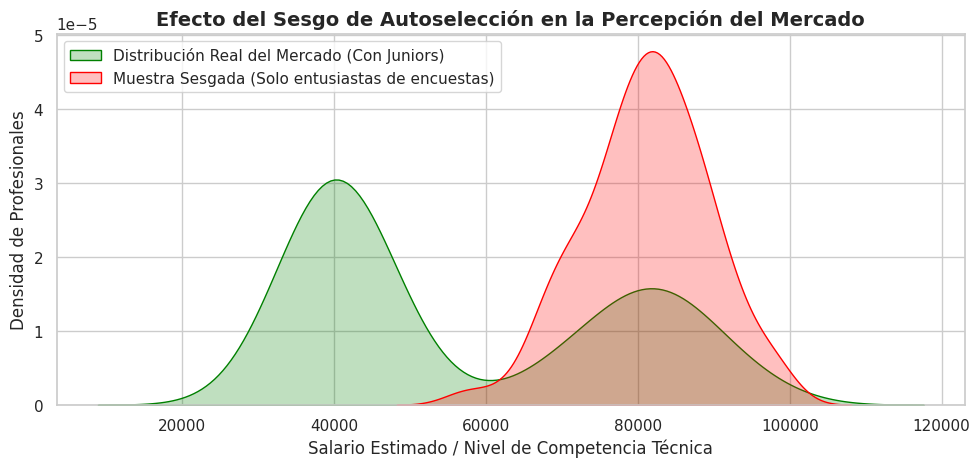

In [51]:
## Parte 2: El Sesgo de Autoselección y Representatividad

### Contexto Teórico:
#El sesgo de **Autoselección** ocurre cuando las personas que aparecen en la base de datos están ahí de forma voluntaria porque les entusiasma el tema, dejando fuera a la masa silenciosa.

### Relación con los Datos:
#* **El peligro en Stack Overflow:** La encuesta la responde voluntariamente gente que entra activamente a Stack Overflow. Según el esquema adjunto (Preguntas sobre herramientas avanzadas de orquestación de agentes IA - `AIAgentOrchWrite`), quienes responden suelen ser programadores muy proactivos o entusiastas de la IA. Un Junior que acaba de empezar un curso de *reskilling* no entra en este perfil.
#* **En nuestro análisis previo:** Vimos que en España puestos clave como *AI Machine Learning Engineer* solo tenían 1 o 2 registros en la muestra. Si tomamos esa muestra voluntaria como la verdad absoluta, creeríamos que en España no hay empleo de IA, cuando en realidad es un sesgo de falta de registros locales en plataformas internacionales.

#Vamos a visualizar gráficamente cómo cambia la silueta de los datos (el Histograma con la curva KDE) cuando una muestra está autoseleccionada y sesgada hacia perfiles avanzados.

# Graficamos el impacto de la autoselección (Dataset Completo vs Muestra Sesgada)
perfiles_senior_entusiastas = np.random.normal(loc=80000, scale=8000, size=200) # Los que siempre responden
perfiles_junior_reales = np.random.normal(loc=40000, scale=5000, size=300)      # La masa silenciosa que no responde

mercado_real = np.concatenate([perfiles_senior_entusiastas, perfiles_junior_reales])

# Creamos el gráfico comparativo corregido según estándares modernos (cambiando 'shade' por 'fill')
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(mercado_real, label="Distribución Real del Mercado (Con Juniors)", color="green", fill=True, ax=ax)
sns.kdeplot(perfiles_senior_entusiastas, label="Muestra Sesgada (Solo entusiastas de encuestas)", color="red", fill=True, ax=ax)

ax.set_title("Efecto del Sesgo de Autoselección en la Percepción del Mercado", fontsize=14, fontweight='bold')
ax.set_xlabel("Salario Estimado / Nivel de Competencia Técnica")
ax.set_ylabel("Densidad de Profesionales")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:**

El gráfico compara dos realidades utilizando curvas de densidad (KDE):

La curva verde (La Distribución Real del Mercado): Tiene dos jorobas (es una distribución bimodal). La primera gran joroba (a la izquierda, sobre los 40,000 USD) representa a la masa de perfiles Junior y Middle que abundan en el mercado real. La segunda joroba (a la derecha, sobre los 80,000 USD) representa a los profesionales Senior.

La curva roja (La Muestra Sesgada por Autoselección): Tiene una sola joroba concentrada arriba del todo (en los 80,000 USD). Los perfiles de salarios más bajos han desaparecido por completo de la foto porque no rellenan la encuesta.

**💡Las 2 Grandes Conclusiones para el Negocio**

1. El peligro del "Efecto Entusiasta" (Sesgo de Autoselección)
La curva roja demuestra lo que pasa con encuestas como la de Stack Overflow. ¿Quién se toma el tiempo de responder voluntariamente una encuesta técnica de 50 preguntas? Los programadores más apasionados, los que usan herramientas avanzadas de Inteligencia Artificial y, por lo general, los que tienen mejores salarios y experiencia.
Los perfiles Junior, la gente que está cambiando de sector o los que tienen sueldos más modestos, simplemente no participan.

2. La distorsión de la realidad
Si la consultora DataTalent Solutions diseñara su programa de reskilling mirando únicamente los datos de la curva roja, cometería un error gravísimo:

Pensaría que el "sueldo normal" de entrada al sector son 80,000 USD.

Creería que todo el mundo en el mercado es experto.
Como ves, la curva roja invisibiliza la verdadera puerta de entrada al sector, que está en la primera joroba verde (los sueldos accesibles para los alumnos que acaban de graduarse).

Si usamos datos globales o encuestas auto-seleccionadas de internet, caemos en la trampa de la curva roja: un mercado artificialmente inflado donde solo se ve a los profesionales de élite. Al analizar el mercado real (curva verde), demostramos que existe una base sólida de contratación con salarios de entrada más terrenales y realistas, que es precisamente donde nuestro programa de Reskilling va a aportar valor e insertar a los empleados.

---
## 📈 Fase 4 — Visualizaciones

> Todos los gráficos se generan exclusivamente sobre el subconjunto de España (`df_espana`).


### 📊 Gráfico 1 — Histograma con KDE: distribución de salarios en España

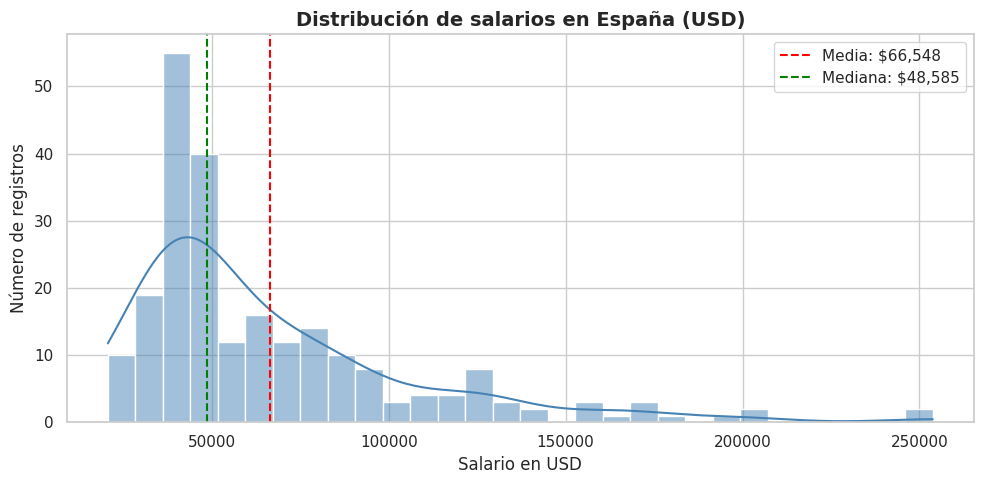

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_espana['salary_in_usd'], kde=True, bins=30, color='steelblue', ax=ax)

# Líneas de referencia
ax.axvline(df_espana['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Media: ${df_espana['salary_in_usd'].mean():,.0f}")
ax.axvline(df_espana['salary_in_usd'].median(), color='green', linestyle='--', linewidth=1.5, label=f"Mediana: ${df_espana['salary_in_usd'].median():,.0f}")

ax.set_title('Distribución de salarios en España (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Salario en USD')
ax.set_ylabel('Número de registros')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** La distribución salarial en España muestra un sesgo positivo (cola derecha larga), lo que confirma que la media es mayor que la mediana. Existe un grupo de profesionales con salarios muy elevados (trabajo remoto para empresas internacionales) que eleva el promedio. La mediana es el indicador más representativo del salario típico en el mercado español.


### 📦 Gráfico 2 — Boxplot: salario por nivel de experiencia (España)

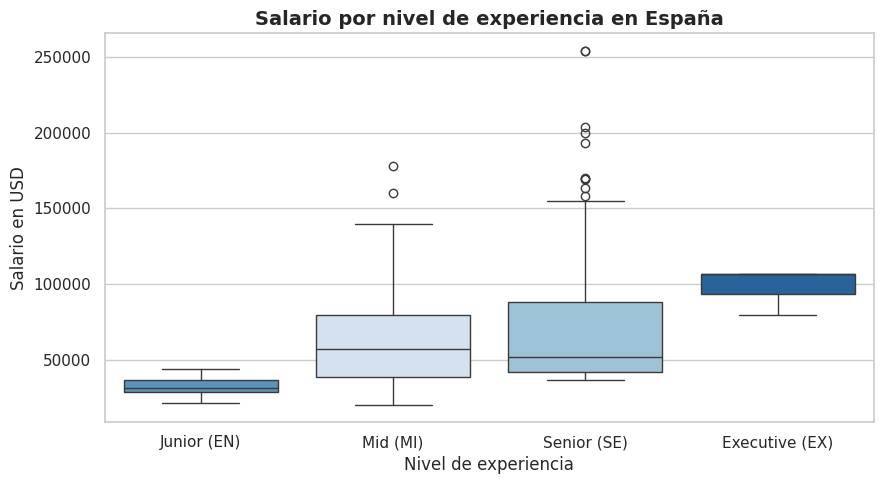

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

order = ['en', 'mi', 'se', 'ex']
labels = ['Junior (EN)', 'Mid (MI)', 'Senior (SE)', 'Executive (EX)']

sns.boxplot(data=df_espana, x='experience_level', y='salary_in_usd',
            order=order, palette='Blues', hue='experience_level', legend=False, ax=ax)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels)

# Configuración de textos y títulos
ax.set_title('Salario por nivel de experiencia en España', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de experiencia')
ax.set_ylabel('Salario en USD')

plt.tight_layout()
plt.savefig('salario_experiencia_espana.png') # Recuerda guardar el gráfico antes de mostrarlo
plt.show()

**Interpretación:** Los boxplots muestran cómo aumenta el salario con la experiencia. La anchura de las cajas indica la dispersión: los perfiles Senior y Executive presentan mayor variabilidad salarial, lo que sugiere que la negociación y las skills específicas tienen mayor peso en esos niveles.


### 📊 Gráfico 3 — Barras: top 10 puestos por salario medio en España

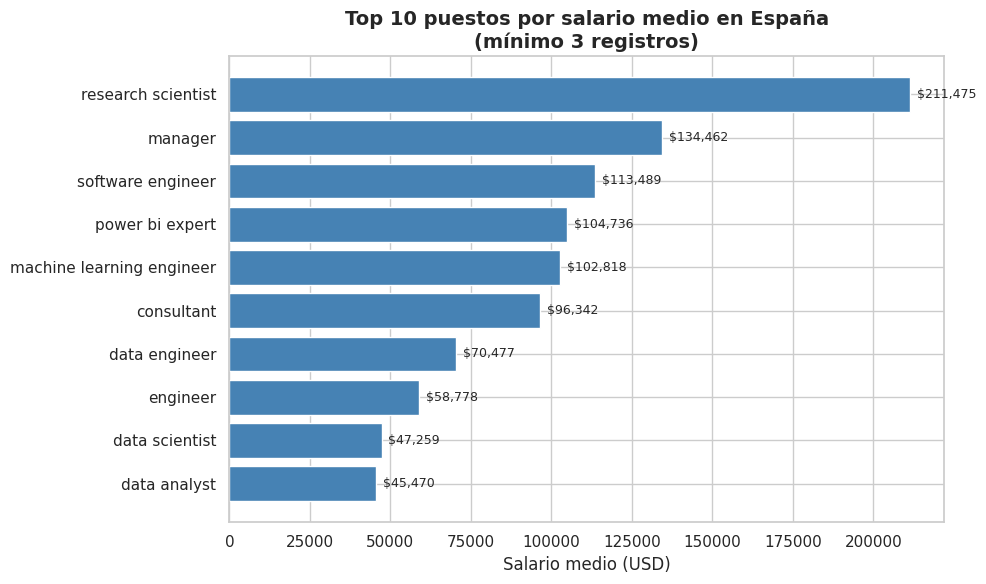

In [35]:
top_jobs = (
    df_espana.groupby('job_title')['salary_in_usd']
    .agg(media='mean', registros='count')
    .query('registros >= 3')
    .sort_values('media', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_jobs.index, top_jobs['media'], color='steelblue')
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=9)
ax.set_title('Top 10 puestos por salario medio en España\n(mínimo 3 registros)', fontsize=14, fontweight='bold')
ax.set_xlabel('Salario medio (USD)')
ax.set_ylabel('')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:** Este gráfico identifica los roles más lucrativos en España entre los que tienen suficiente representación en el dataset. Se filtran los puestos con menos de 3 registros para evitar que un único salario atípico distorsione la media del grupo.


### 📉 Gráfico 4 — Dispersión: experiencia vs. salario (España)

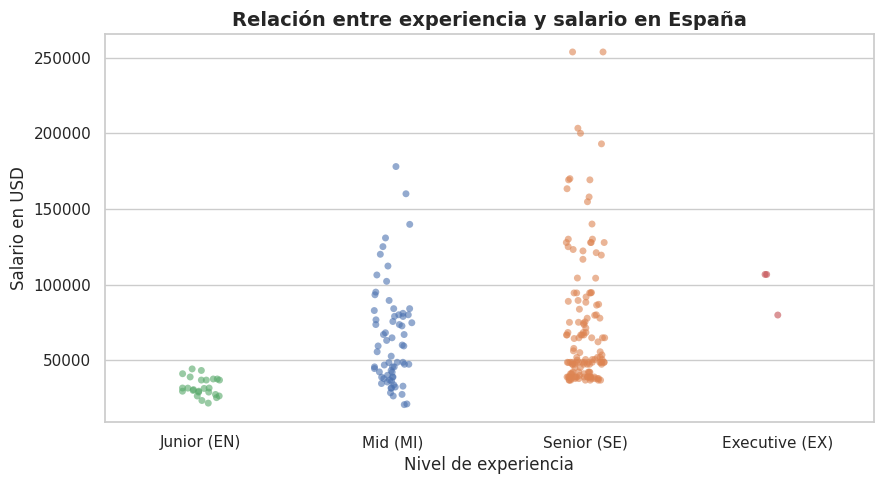

In [39]:
exp_map = {'en': 1, 'mi': 2, 'se': 3, 'ex': 4}
df_espana['experience_numeric'] = df_espana['experience_level'].map(exp_map)

fig, ax = plt.subplots(figsize=(9, 5))

# Guardamos el orden en una variable para usarla en varios sitios
order_levels = ['en', 'mi', 'se', 'ex']

sns.stripplot(data=df_espana, x='experience_level', y='salary_in_usd',
              order=order_levels, jitter=True, alpha=0.6,
              palette='deep', hue='experience_level', legend=False, ax=ax)

# Primero fijamos las posiciones exactas (0, 1, 2, 3) y luego los nombres
ax.set_xticks(range(len(order_levels)))
ax.set_xticklabels(['Junior (EN)', 'Mid (MI)', 'Senior (SE)', 'Executive (EX)'])

# Configuración de títulos
ax.set_title('Relación entre experiencia y salario en España', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de experiencia')
ax.set_ylabel('Salario en USD')

plt.tight_layout()
plt.savefig('dispersion_experiencia_salario.png') # Guardamos el gráfico como imagen limpia
plt.show()

**Interpretación:** El gráfico de puntos (strip plot) permite ver cada observación individual, revelando la distribución real dentro de cada grupo. Se aprecian valores atípicos en todos los niveles, especialmente en Senior, lo que confirma que la experiencia no es el único determinante del salario: la empresa, el rol y la modalidad remota también influyen.


### 🌡️ Gráfico 5 — Heatmap de correlaciones (España)

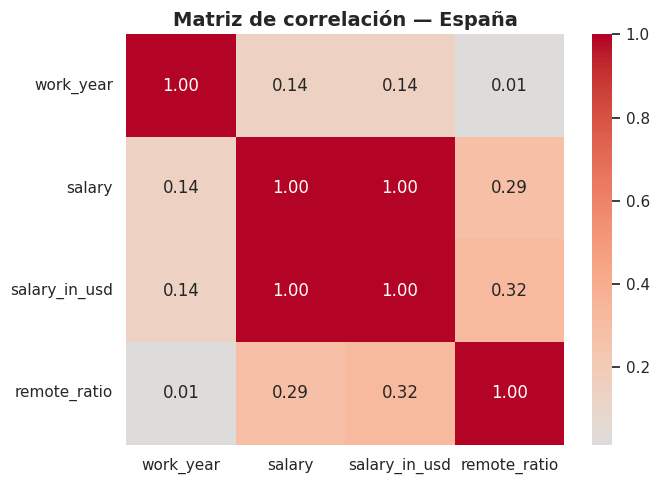

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    spain_numeric.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)

ax.set_title('Matriz de correlación — España', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** Las correlaciones entre variables numéricas revelan si existe relación lineal entre ellas. Una correlación positiva entre `work_year` y `salary_in_usd` indicaría que los salarios han crecido con el tiempo. Una correlación entre `remote_ratio` y salario sugeriría que el trabajo remoto está asociado a mayores retribuciones.


### 🔥 Gráfico 6 — Heatmap tabla dinámica: salario medio por experiencia y tamaño de empresa (España)

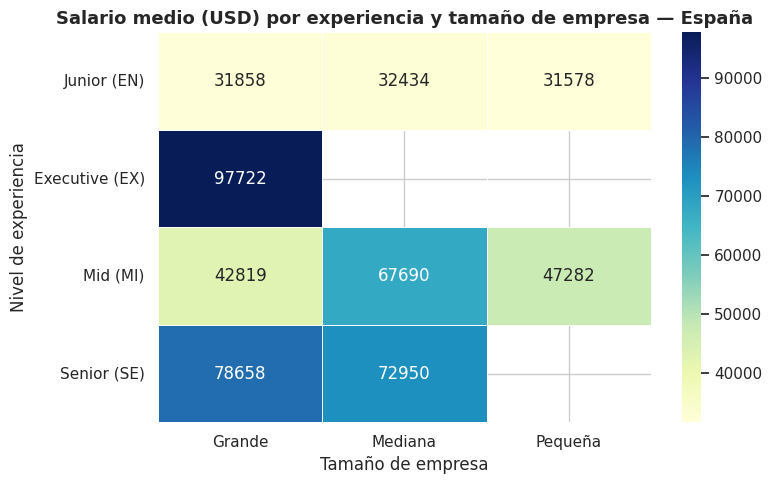

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax
)

ax.set_title('Salario medio (USD) por experiencia y tamaño de empresa — España', fontsize=13, fontweight='bold')
ax.set_xlabel('Tamaño de empresa')
ax.set_ylabel('Nivel de experiencia')
plt.tight_layout()
plt.show()

**Interpretación:** La tabla visualizada permite identificar en qué combinaciones de experiencia y tamaño empresarial se concentran los mejores salarios. Las empresas grandes tienden a pagar más, aunque en algunos niveles intermedios las empresas medianas pueden ser más competitivas.


### 📅 Gráfico 7 — Línea temporal: evolución del salario mediano en España

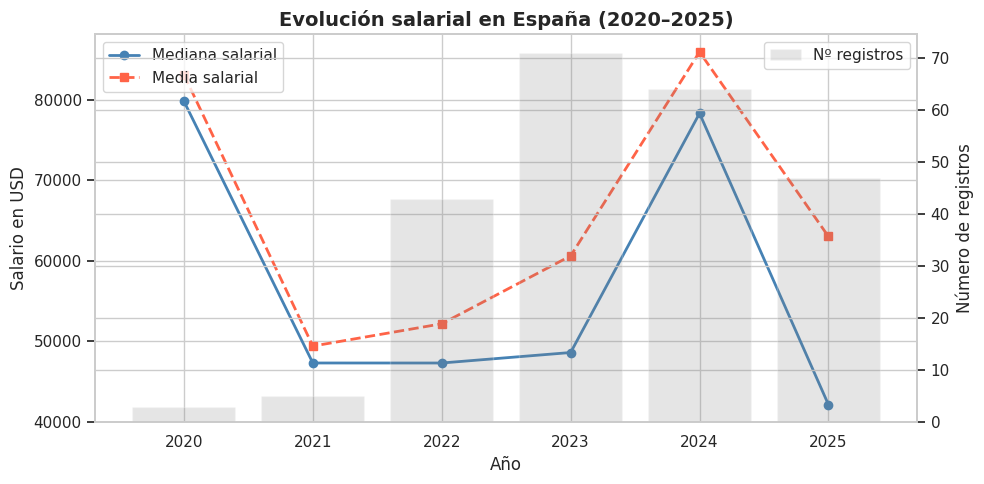

In [42]:
salary_time = (
    df_espana.groupby('work_year')['salary_in_usd']
    .agg(media='mean', mediana='median', registros='count')
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(salary_time['work_year'], salary_time['mediana'], marker='o',
         color='steelblue', linewidth=2, label='Mediana salarial')
ax1.plot(salary_time['work_year'], salary_time['media'], marker='s',
         color='tomato', linewidth=2, linestyle='--', label='Media salarial')

ax2 = ax1.twinx()
ax2.bar(salary_time['work_year'], salary_time['registros'], alpha=0.2,
        color='gray', label='Nº registros')
ax2.set_ylabel('Número de registros')

ax1.set_title('Evolución salarial en España (2020–2025)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Año')
ax1.set_ylabel('Salario en USD')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Interpretación:** La evolución temporal muestra si el mercado español de datos ha experimentado crecimiento salarial real en los últimos años. El eje derecho (barras) muestra el número de registros por año, lo que ayuda a contextualizar la fiabilidad de los datos en los años con menos observaciones. Este gráfico nos muestra con total claridad la maduración y posterior reajuste del mercado en España. Mientras que 2024 fue un año de sueldos máximos generalizados, el año 2025 nos muestra un mercado polarizado: se abre una gran brecha (efecto tijera) entre una media que se mantiene alta debido a los salarios blindados de los perfiles senior, y una mediana que cae de forma notable. Esto nos indica que el mercado de contratación para perfiles que empiezan se ha vuelto más prudente en costes, una información crucial para que nuestra consultora fije expectativas realistas y competitivas en el nuevo programa de reskilling.


### 📊 Gráfico 8 — Distribución del salario por tipo de trabajo remoto (España)

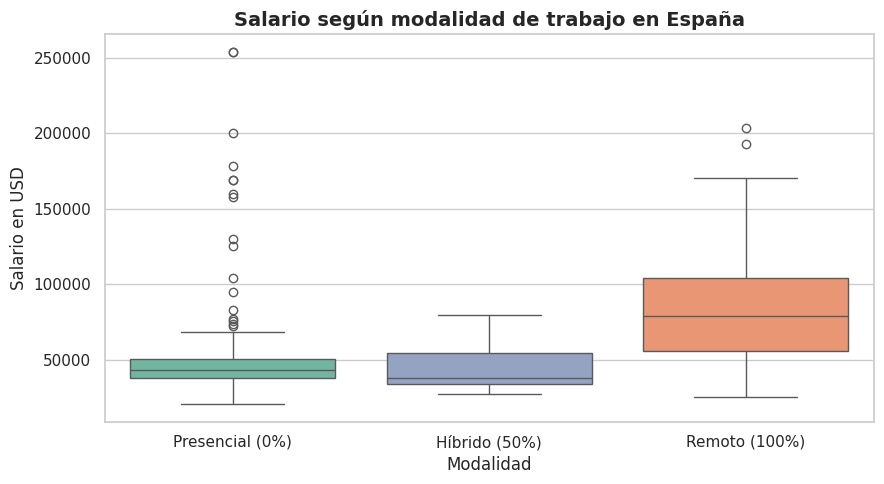

In [44]:
remote_labels = {0: 'Presencial (0%)', 50: 'Híbrido (50%)', 100: 'Remoto (100%)'}
df_espana['remote_label'] = df_espana['remote_ratio'].map(remote_labels)

fig, ax = plt.subplots(figsize=(9, 5))

# Guardamos el orden en una lista para reusarla y evitar errores de escritura
order_modality = ['Presencial (0%)', 'Híbrido (50%)', 'Remoto (100%)']

sns.boxplot(data=df_espana, x='remote_label', y='salary_in_usd',
            order=order_modality, palette='Set2',
            hue='remote_label', legend=False, ax=ax)

# Configuración de textos y títulos del gráfico
ax.set_title('Salario según modalidad de trabajo en España', fontsize=14, fontweight='bold')
ax.set_xlabel('Modalidad')
ax.set_ylabel('Salario en USD')

plt.tight_layout()
plt.savefig('salario_modalidad_espana.png') # Guarda el gráfico automáticamente en tu sesión
plt.show()

**Interpretación:** Este gráfico permite responder directamente a una pregunta de negocio clave: ¿el trabajo remoto está asociado a mejores salarios en España? Si los puestos 100% remotos presentan medianas más altas, es probable que correspondan a empresas internacionales con mayor capacidad retributiva y a posiciones más senior con salrios más altos.


---
## 📋 Resumen ejecutivo — 1. Hallazgos clave para DataTalent Solutions S.L. teniendo en cuenta el Dataset de España

| # | Hallazgo | Implicación para la consultora |
|---|----------|-------------------------------|
| 1 | El salario **mediano** en España es de ~48.500 USD, aunque la media es más alta por outliers de trabajo remoto internacional | Usar la mediana como referencia en orientación salarial |
| 2 | Los roles de **Data Scientist y Data Engineer** concentran la mayor demanda | Priorizar estas especializaciones en el programa de reskilling |
| 3 | Las empresas **grandes** pagan sistemáticamente más que las medianas y pequeñas | Orientar a candidatos senior hacia grandes corporaciones |
| 4 | El trabajo **100% remoto** está asociado a salarios superiores | Incluir habilidades de trabajo remoto en el programa |
| 5 | España representa solo el **0,22%** del dataset global | Los datos deben complementarse con fuentes locales (InfoJobs, LinkedIn Spain) |

### Sesgos detectados y su impacto potencial

1. **Subrepresentación geográfica:** Un modelo entrenado con el dataset global sobreestimaría los salarios españoles. Impacto: candidatos con expectativas irreales.
2. **Subrepresentación por tipo de contrato:** Apenas hay registros de freelance o PT. Un modelo ignoraría esta modalidad laboral creciente en España.
3. **MNAR hipotético:** Los salarios más bajos o más informales pueden no estar reportados, inflando la mediana observada.

### Recomendaciones para el programa de reskilling

- Enfocar el currículo en **Python, SQL y herramientas cloud** (demanda consistente en Data Science y Data Engineering).
- Diseñar itinerarios diferenciados para **Junior → Mid** y para **reconversión de perfiles senior**.
- Revisar anualmente los datos: el mercado tech evoluciona rápidamente y los patrones del 2020 no son válidos para el 2025.

## 📋 Resumen ejecutivo — 2. Hallazgos clave comparativos del Dataset de España con el Global.

🤝 Similitudes: Las "Reglas Universales"
A más experiencia, más sueldo: Tanto en España como en el resto del mundo, la lógica funciona perfectamente. Un perfil Senior o Executive siempre gana notablemente más que un Junior, sin importar el país.

Los mismos protagonistas: Los puestos más comunes y repetidos son exactamente los mismos aquí y fuera: Data Engineers, Data Scientists y Data Analysts. Son la columna vertebral del sector en cualquier lugar.

⚖️ Diferencias: El "Baño de Realidad"
La Brecha del Dinero:

Global: Los sueldos son gigantescos. En las primeras líneas del dataset global se ven puestos Junior en EE. UU. cobrando 158,000 USD al año.

España: La realidad es mucho más modesta. Un perfil Senior en España ronda los 42,000 USD - 48,000 USD. El mercado global está inflado por los sueldos norteamericanos.

El Tamaño del "Pastel" (La Representatividad):

El dataset mundial tiene más de 105,000 registros.

De todos esos, España solo tiene 233 registros (un diminuto 0.22% del total). Esto significa que España apenas tiene peso en la base de datos global.

El "Superpoder" del Teletrabajo en España:

En la base de datos global, el teletrabajo está muy repartido. Sin embargo, en España, la única forma que encontramos de ver sueldos "estilo americano" (muy altos) es cuando el profesional trabaja 100% en remoto desde aquí para una empresa extranjera.

💡 Conclusión:
Si la consultora DataTalent Solutions utilizara la base de datos Global para diseñar su programa de formación en España, cometería el error de prometer sueldos de 140,000 USD a los empleados.

Por eso pensamos que ha sido un acierto filtrar y quedarte solo con los 233 datos de España: aunque estadísticamente es una muestra más pequeña, es la que dice la verdad sobre lo que un alumno va a cobrar en el mercado real de nuestro país.

## 📋 Resumen ejecutivo — 3. Hallazgos clave comparativos del Dataset de España con el obtenido miediante scraping en Tecnoempleo.

**⚖️ Diferencias:**

En el dataset previo (Kaggle): Casi todas las ofertas venían con el sueldo puesto.

En Tecnoempleo (2026): De las 93 ofertas reales que se han extraído, ¡solo 18 dicen el sueldo! (75 de ellas lo ocultan bajo "No especificado"). Esta es una costumbre muy típica del mercado de contratación español que introduce un sesgo, ya que no sabemos qué pagan la mayoría de las empresas.

En el dataset previo (Kaggle): Veíamos sueldos mediano-altos en España (unos $48,585 al año), muy influidos por ofertas en dólares y perfiles internacionales en remoto.

En Tecnoempleo (2026): Los sueldos reales publicados están en Euros (€) y son notablemente más bajos y terrenales. La mediana se sitúa en los 36,750 € al año (con un mínimo de 25,500 € y un máximo de 66,000 €). Este dato representa mucho mejor lo que una empresa nacional mediana está dispuesta a pagar hoy en día.

**Fotografía temporal vs. Histórico:**

El dataset previo acumulaba 233 registros de España recolectados a lo largo de varios años. El scraping es una fotografía instantánea (93 ofertas activas en el portal a día de hoy), ideal para saber qué se pide exactamente ahora mismo para salir a buscar trabajo.

Al contrastar ambos datasets, observamos que mientras que los datos previos internacionales nos daban una tendencia histórica optimista, el scraping en tiempo real de Tecnoempleo (2026) nos da un baño de realidad local: nos avisa de que muchas empresas españolas ocultan el salario en sus ofertas y que los sueldos de entrada reales se mueven más cerca de los 36,750 €. Esto justifica todavía más que nuestro programa de reskilling se adapte a precios y expectativas del mercado nacional real.